# Predicting Medical Insurance Costs

## Dataset Description

This project uses `insurance_medical_cost_cleaned.csv`, a cleaned medical insurance cost dataset of 1,338 individuals.

Target variable:
- charges — annual medical insurance cost, in USD

Predictors:
- age — Age of the individual (18–64)
- sex — Sex, encoded as 0/1
- bmi — Body mass index
- children — Number of dependents covered
- smoker — Smoking status, encoded as 0 (non-smoker) / 1 (smoker)
- region_northwest, region_southeast, region_southwest — One-hot encoded region (northeast is the dropped baseline)

Goal: understand what drives medical insurance charges, and build models to (1) predict the exact charge for a person and (2) predict whether a person is a smoker from their profile.

The sections below cover: summary statistics, distribution analysis, relationships between variables, two prediction models, and a conclusion.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# 1. Load & sanity-check

In [4]:
from scipy.stats import skew

df = pd.read_csv('insurance_medical_cost_cleaned.csv')

print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nHead:")
print(df.head())

print("\nUnique values check:")
print("sex:", df['sex'].unique())
print("smoker:", df['smoker'].unique())


Shape: (1338, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB

Head:
   age  sex    bmi  children  smoker   charges  region_northwest  \
0   56    0  27.02         2       0  23156.27                 1   
1   46    1  29.40         1       0  19456.82                 0   
2   32    0  25.97         5       0  20395.06                 1   
3   60    0  30.80         1      


# 2. Summary statistics

In [5]:

print("\n--- Describe (all numeric columns) ---")
print(df.describe())

print("\n--- Median (key columns) ---")
print(df[['age', 'bmi', 'charges']].median())

print("\n--- IQR (key columns) ---")
for col in ['age', 'bmi', 'charges']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")



--- Describe (all numeric columns) ---
               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     41.036622     0.493274    30.448475     1.092676     0.207773   
std      13.528861     0.500142     5.966884     1.228710     0.405865   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      29.000000     0.000000    26.332500     0.000000     0.000000   
50%      42.000000     0.000000    30.620000     1.000000     0.000000   
75%      52.000000     1.000000    34.510000     2.000000     0.000000   
max      64.000000     1.000000    47.260000     5.000000     1.000000   

            charges  region_northwest  region_southeast  region_southwest  
count   1338.000000       1338.000000       1338.000000       1338.000000  
mean   26947.834066          0.256353          0.248879          0.243647  
std    12996.479469          0.436782          0.432525          


# 3. Distribution analysis


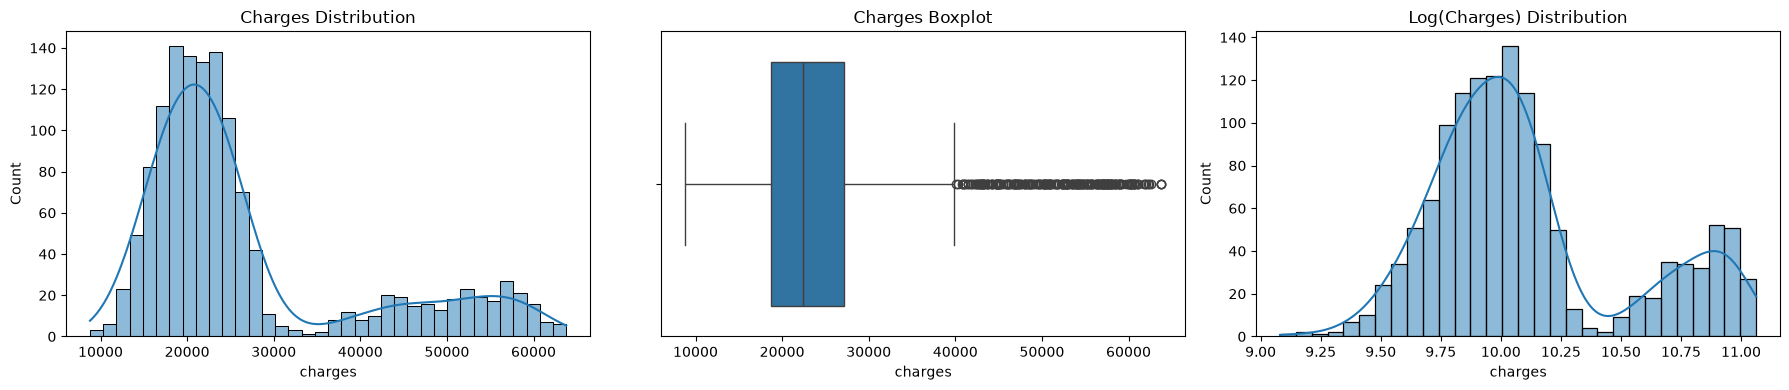


Skewness of charges: 1.371
Skewness of log(charges): 0.806


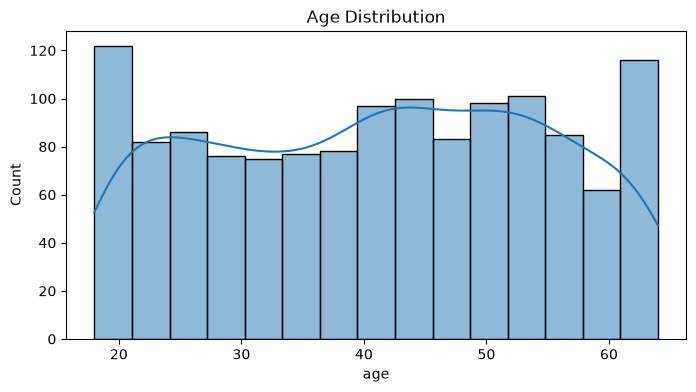


Age group counts:
age_group
18-30    366
31-40    264
41-50    321
51-65    387
Name: count, dtype: int64


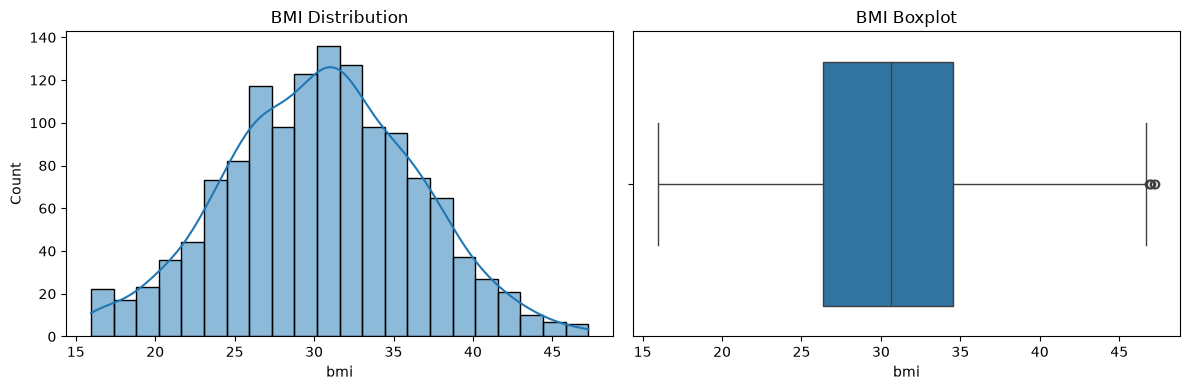


Skewness of bmi: 0.005

BMI category counts:
bmi_category
Obese          717
Overweight     379
Normal         209
Underweight     33
Name: count, dtype: int64


In [6]:
# --- charges: histogram, boxplot, skewness ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Charges Distribution')

sns.boxplot(x=df['charges'], ax=axes[1])
axes[1].set_title('Charges Boxplot')

sns.histplot(np.log(df['charges']), kde=True, ax=axes[2])
axes[2].set_title('Log(Charges) Distribution')
plt.tight_layout()
plt.show()

print(f"\nSkewness of charges: {skew(df['charges']):.3f}")
print(f"Skewness of log(charges): {skew(np.log(df['charges'])):.3f}")

# --- age: histogram + age groups ---
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.show()

df['age_group'] = pd.cut(df['age'], bins=[17, 30, 40, 50, 65],
                          labels=['18-30', '31-40', '41-50', '51-65'])
print("\nAge group counts:")
print(df['age_group'].value_counts().sort_index())

# --- bmi: histogram + boxplot + WHO categories ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bmi'], kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution')
sns.boxplot(x=df['bmi'], ax=axes[1])
axes[1].set_title('BMI Boxplot')
plt.tight_layout()
plt.show()

print(f"\nSkewness of bmi: {skew(df['bmi']):.3f}")

df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print("\nBMI category counts:")
print(df['bmi_category'].value_counts())



# 4. Relationships between variables

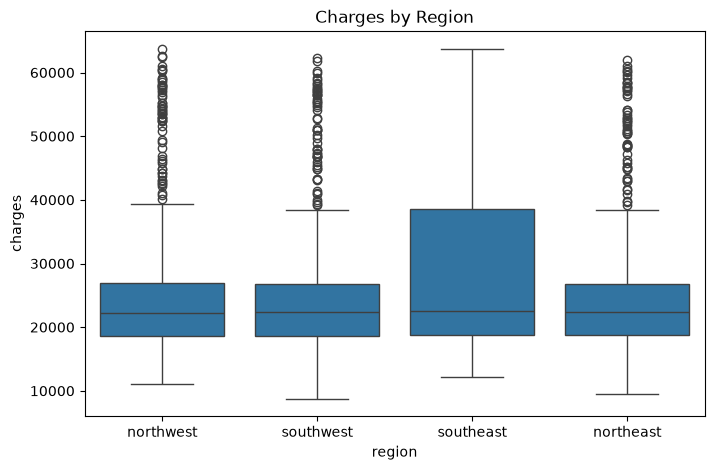


Charges by region:
           count          mean           std       min         25%        50%  \
region                                                                          
northeast  336.0  26337.418810  12394.934161   9421.76  18701.0725  22420.110   
northwest  343.0  26649.418601  12947.375974  11026.53  18588.4650  22254.210   
southeast  333.0  28373.406967  14136.120245  12135.05  18743.6800  22552.190   
southwest  326.0  26434.767362  12374.946982   8783.15  18676.7200  22304.505   

                  75%       max  
region                           
northeast  26850.8425  61960.43  
northwest  26933.2100  63770.43  
southeast  38558.6200  63770.43  
southwest  26736.9275  62266.30  


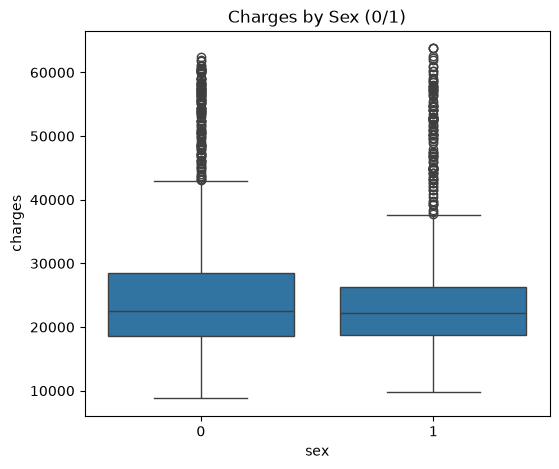


Charges by sex:
     count          mean           std      min         25%        50%  \
sex                                                                      
0    678.0  27748.009853  13650.086324  8783.15  18667.6675  22553.050   
1    660.0  26125.835303  12244.886647  9759.64  18693.7175  22232.405   

            75%       max  
sex                        
0    28460.2125  62394.44  
1    26336.9800  63770.43  


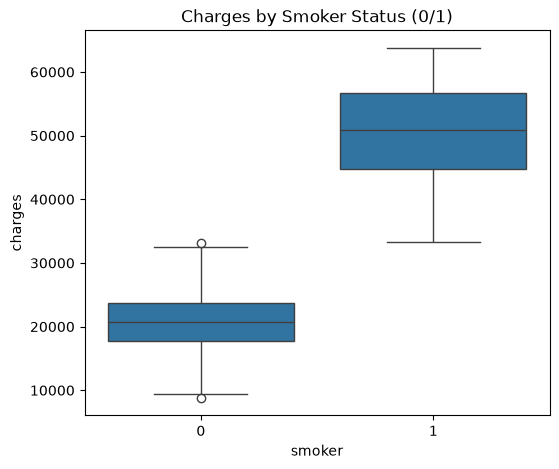


Charges by smoker status:
         count          mean          std       min         25%        50%  \
smoker                                                                       
0       1060.0  20779.834538  4069.557618   8783.15  17790.9225  20734.725   
1        278.0  50466.105647  7160.113002  33305.01  44832.3825  50948.215   

               75%       max  
smoker                        
0       23734.1350  33075.95  
1       56642.1275  63770.43  


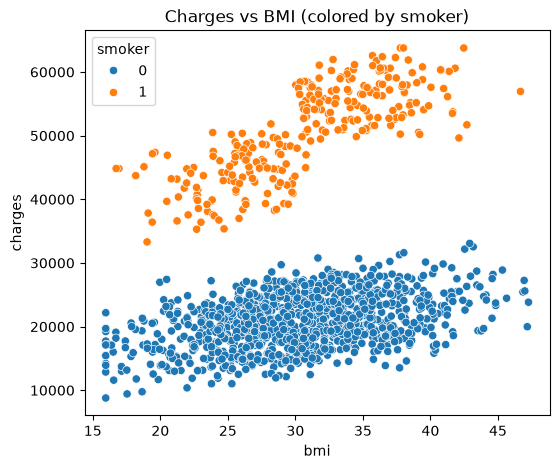

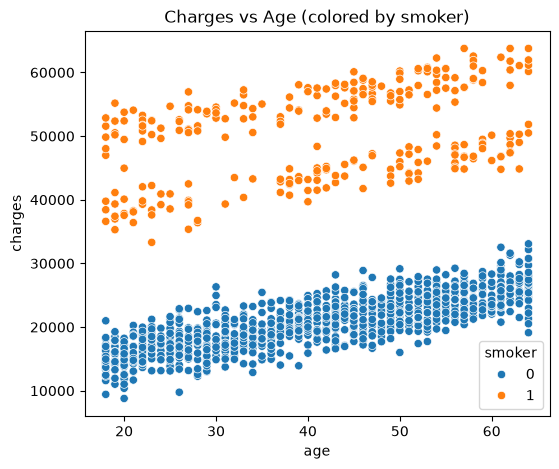

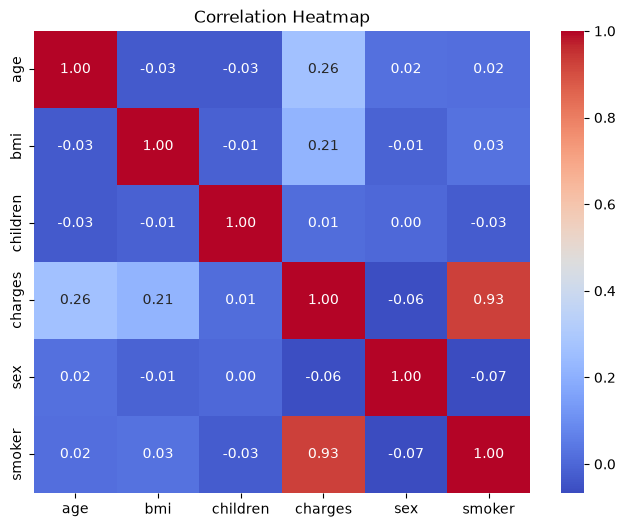

In [7]:
# Reconstruct a single 'region' column from one-hot columns
def get_region(row):
    if row['region_northwest'] == 1:
        return 'northwest'
    elif row['region_southeast'] == 1:
        return 'southeast'
    elif row['region_southwest'] == 1:
        return 'southwest'
    else:
        return 'northeast'  # baseline dropped column

df['region'] = df.apply(get_region, axis=1)

# --- charges vs region ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()
print("\nCharges by region:")
print(df.groupby('region')['charges'].describe())

# --- charges vs sex ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex (0/1)')
plt.show()
print("\nCharges by sex:")
print(df.groupby('sex')['charges'].describe())

# --- charges vs smoker (strongest relationship usually) ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status (0/1)')
plt.show()
print("\nCharges by smoker status:")
print(df.groupby('smoker')['charges'].describe())

# --- charges vs bmi (scatter) ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI (colored by smoker)')
plt.show()

# --- charges vs age (scatter) ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Charges vs Age (colored by smoker)')
plt.show()

# --- correlation heatmap ---
plt.figure(figsize=(8, 6))
numeric_cols = ['age', 'bmi', 'children', 'charges', 'sex', 'smoker']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

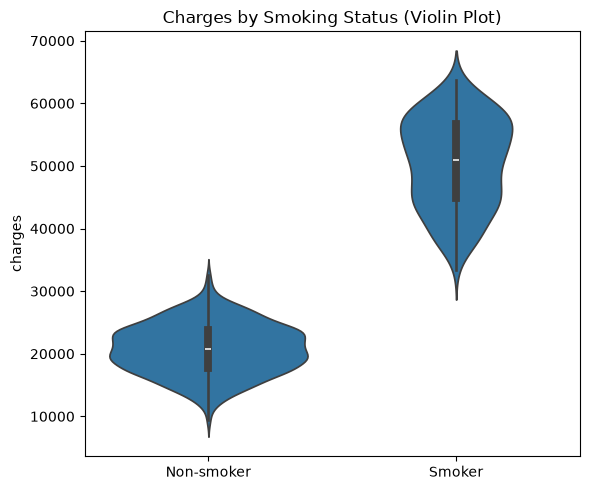

In [8]:
# --- charges vs smoker (violin plot) ---
# A violin plot shows the full shape of the distribution for each group,
# not just the box/quartiles - useful here since charges are bimodal.
plt.figure(figsize=(6, 5))
sns.violinplot(x='smoker', y='charges', data=df)
plt.xticks([0, 1], ['Non-smoker', 'Smoker'])
plt.title('Charges by Smoking Status (Violin Plot)')
plt.xlabel('')
plt.tight_layout()
plt.show()


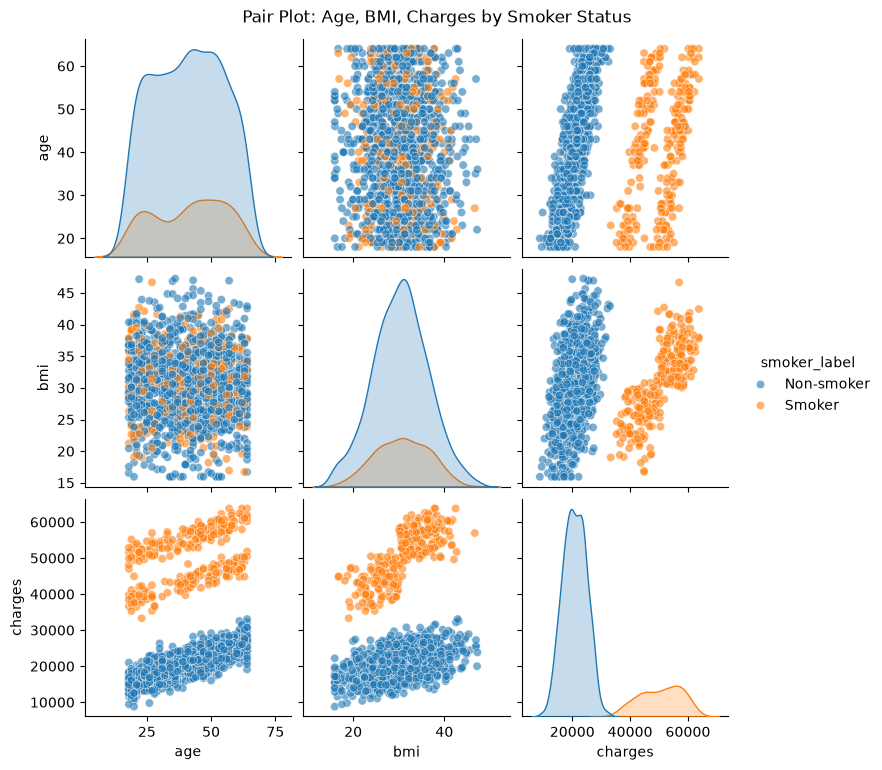

In [9]:
# --- pair plot: age, bmi, charges, colored by smoker status ---
# Combines several relationships into one view - shows how the smoker
# and non-smoker groups separate across every pairing of these variables.
df['smoker_label'] = df['smoker'].map({0: 'Non-smoker', 1: 'Smoker'})
sns.pairplot(df[['age', 'bmi', 'charges', 'smoker_label']],
             hue='smoker_label', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot: Age, BMI, Charges by Smoker Status', y=1.02)
plt.show()


## 5. Prediction Model 1 — Regression (predict exact charges)
Compare Linear Regression vs. Random Forest on an 80/20 train/test split.

--- Regression model comparison (test set) ---
 Linear Regression:  R2 = 0.965   MAE = $1,861   RMSE = $2,437
     Random Forest:  R2 = 0.983   MAE = $1,328   RMSE = $1,685

Feature importance (Random Forest):
  smoker               0.869
  age                  0.067
  bmi                  0.063
  children             0.001
  region_southeast     0.000
  region_southwest     0.000
  region_northwest     0.000
  sex                  0.000


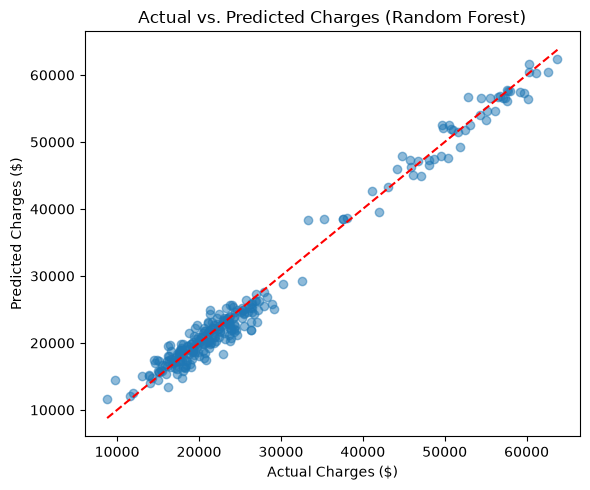

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['age', 'sex', 'bmi', 'children', 'smoker',
        'region_northwest', 'region_southeast', 'region_southwest']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- Linear Regression ---
lin_reg = LinearRegression().fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

# --- Random Forest Regression ---
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

def report(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:>18}:  R2 = {r2:.3f}   MAE = ${mae:,.0f}   RMSE = ${rmse:,.0f}")

print("--- Regression model comparison (test set) ---")
report("Linear Regression", y_test, lin_pred)
report("Random Forest", y_test, rf_pred)

print("\nFeature importance (Random Forest):")
for feat, imp in sorted(zip(X.columns, rf_reg.feature_importances_), key=lambda t: -t[1]):
    print(f"  {feat:<20} {imp:.3f}")

# --- Actual vs Predicted plot (best model) ---
plt.figure(figsize=(6, 5))
plt.scatter(y_test, rf_pred, alpha=0.5)
lims = [min(y_test.min(), rf_pred.min()), max(y_test.max(), rf_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs. Predicted Charges (Random Forest)')
plt.tight_layout()
plt.show()


## 6. Prediction Model 2 — Classification (predict smoker status)
Logistic Regression, evaluated with accuracy / precision / recall / F1 and a confusion matrix.

--- Smoker classification (test set) ---
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 score:  1.000


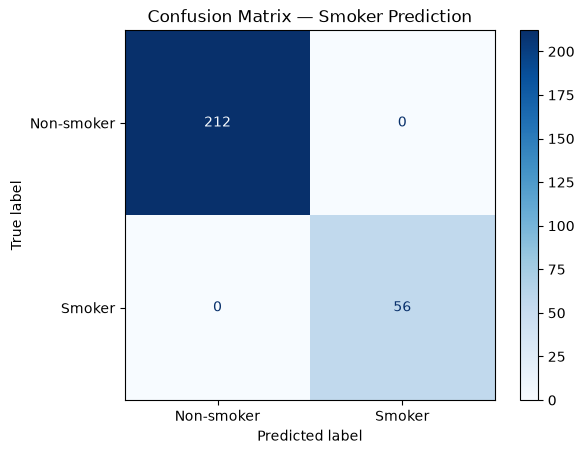


Note: charges is a very strong predictor of smoker status (corr = 0.93), which is why this classifier scores almost perfectly here.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

Xc = df[['age', 'sex', 'bmi', 'children', 'charges',
         'region_northwest', 'region_southeast', 'region_southwest']]
yc = df['smoker']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf = LogisticRegression(max_iter=1000).fit(Xc_train, yc_train)
pred = clf.predict(Xc_test)

print("--- Smoker classification (test set) ---")
print(f"Accuracy:  {accuracy_score(yc_test, pred):.3f}")
print(f"Precision: {precision_score(yc_test, pred):.3f}")
print(f"Recall:    {recall_score(yc_test, pred):.3f}")
print(f"F1 score:  {f1_score(yc_test, pred):.3f}")

cm = confusion_matrix(yc_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-smoker', 'Smoker'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Smoker Prediction')
plt.show()

print("\nNote: charges is a very strong predictor of smoker status "
      "(corr = {:.2f}), which is why this classifier scores almost "
      "perfectly here.".format(df['charges'].corr(df['smoker'])))


## Conclusion

Key findings from the EDA:
- Charges are right-skewed (skewness ≈ 1.37) and clearly bimodal — driven almost entirely by smoking status, not by any other single factor.
- Smokers pay roughly 2.4x more on average than non-smokers (~$50,466 vs. ~$20,780).
- Age and BMI both correlate positively with charges, but far more weakly (corr ≈ 0.26 and 0.21) than smoker status (corr ≈ 0.93).
- Region and sex have almost no effect on charges — their boxplots overlap heavily across groups.

Prediction Model 1 — Regression (predicting exact charges):
- We compared Linear Regression and Random Forest on the same 80/20 train/test split.
- Random Forest performed better on every metric: R² = 0.983, MAE = $1,328, RMSE = $1,685, vs. Linear Regression's R² = 0.965, MAE = $1,861.
- Feature importance confirms the EDA: smoker alone accounts for 87% of the Random Forest's predictive power; age and bmi contribute far less, and region/sex contribute almost nothing.

Prediction Model 2 — Classification (predicting smoker status):
- Logistic Regression achieved 100% accuracy, precision, recall, and F1 on the test set.
- This is expected rather than suspicious: since charges is included as a feature and is extremely strongly correlated with smoker (corr ≈ 0.93), the two classes are almost linearly separable.
- Limitation: this setup assumes we already know a person's charges, which won't be true before they're actually billed. A more realistic, harder version of this task would predict smoker status without using charges as an input — a good next step if this project were extended.

Overall takeaway: smoking status is by far the single strongest driver of medical insurance cost in this dataset, dominating age, BMI, region, and sex combined.